In [12]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [13]:
np.random.seed(42)
df = pd.DataFrame({
    '年龄': np.concatenate([np.random.randint(18, 35, 70), np.random.randint(30, 50, 80), np.random.randint(40, 65, 50)]),
    '年收入_万': np.concatenate([np.random.uniform(10, 30, 70), np.random.uniform(40, 80, 80), np.random.uniform(20, 45, 50)]),
    '消费分数': np.concatenate([np.random.uniform(60, 100, 70), np.random.uniform(60, 95, 80), np.random.uniform(10, 40, 50)]),
})

In [14]:
df

,年龄,年收入_万,消费分数
0,24,16.973320,73.462169
1,32,11.923531,86.228905
2,28,28.810465,75.415865
3,25,17.951440,87.264547
4,24,20.355027,73.624983
...,...,...,...
195,59,26.849028,31.791911
196,43,25.364728,26.423389
197,58,29.431477,23.527313
198,42,20.974078,37.314138


In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [16]:
inertias = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)

    km.fit(X_scaled)
    inertias.append(km.inertia_)

E:\anaconda3\envs\MachineLearning\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
E:\anaconda3\envs\MachineLearning\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
E:\anaconda3\envs\MachineLearning\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
E:\anaconda3\envs\MachineLearning\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is k

In [17]:
inertias

[600.0,
 324.6934679365812,
 134.47769448934648,
 109.26858524616551,
 87.40918312066833,
 77.33884220636048,
 68.63698104117981,
 62.59335119087787,
 56.73773865597089,
 53.75509074693497]

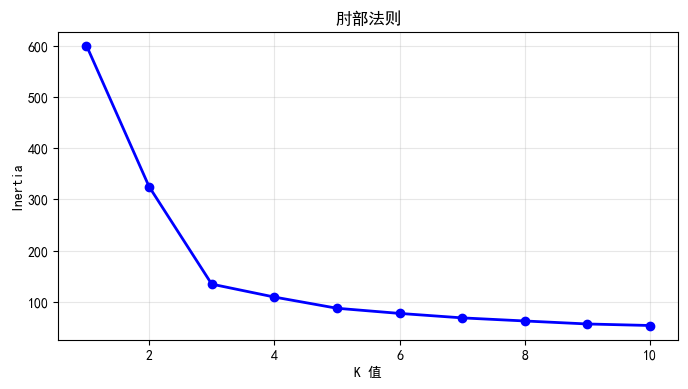

In [18]:
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertias, 'bo-', linewidth=2)
plt.xlabel('K 值')
plt.ylabel('Inertia')
plt.title('肘部法则')
plt.grid(True, alpha=0.3)

plt.show()

In [19]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df['簇标签'] = kmeans.fit_predict(X_scaled)

E:\anaconda3\envs\MachineLearning\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [20]:
df

,年龄,年收入_万,消费分数,簇标签
0,24,16.973320,73.462169,2
1,32,11.923531,86.228905,2
2,28,28.810465,75.415865,2
3,25,17.951440,87.264547,2
4,24,20.355027,73.624983,2
...,...,...,...,...
195,59,26.849028,31.791911,1
196,43,25.364728,26.423389,1
197,58,29.431477,23.527313,1
198,42,20.974078,37.314138,1


In [21]:
print("各簇样本数:")
print(df['簇标签'].value_counts().sort_index())

各簇样本数:
簇标签
0    80
1    50
2    70
Name: count, dtype: int64
